In [1]:
%pip install lightgbm xgboost catboost


  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
  Using cached xgboost-3.0.2-py3-none-manylinux_2_28_x86_64.whl (253.9 MB)
  Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl (99.2 MB)
  Using cached nvidia_nccl_cu12-2.26.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (318.1 MB)
  Using cached graphviz-0.20.3-py3-none-any.whl (47 kB)
  Using cached plotly-6.1.2-py3-none-any.whl (16.3 MB)
  Using cached narwhals-1.41.0-py3-none-any.whl (357 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import pandas as pd
import joblib
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.simulator_grid import *
from src.config import *
from src.utils import get_latest_file

import json

pd.set_option("display.max_columns", None)

from src.simulator_grid import run_parallel_simulations

: 

In [3]:
bets_df, summary = run_season_simulation(
            seasons_to_test=["2022-23","2023-24"], #, "2023-24"],
            exclude_future_seasons=True,
            min_ev=0.05,
            odds_max=99,
            odds_min=1.15,
            prob_diff=0.05,
            ev_diff_min=0.1,
            bankroll=1000,
            max_risk=0.02,
            streak_limit=5,
            bankroll_stop=0.5,
            skip_first_n=0,
            model_identifier="odds_simple",
            reset_bankroll_each_season=False,
            parallel = True
        )


#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)



--- Saison: 2022-23 ---
Model in parallel mode: True. n_jobs set to -1
Chargement du modèle existant pour 2022-23 (odds_simple)
Modèle chargé depuis data/models/simulations/model_2022-23_odds_simple.joblib
dataset cols before SIM : ['GAME_ID', 'TEAM_ID', 'GAME_DATE', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'PTS', 'PLUS_MINUS', 'MINUTES_PLAYED', 'OPP_TEAM_ID', 'OPP_GAME_DATE', 'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT', 'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT', 'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT', 'OPP_OREB', 'OPP_DREB', 'OPP_REB', 'OPP_AST', 'OPP_STL', 'OPP_BLK', 'OPP_TO', 'OPP_PF', 'OPP_PTS', 'OPP_PLUS_MINUS', 'OPP_MINUTES_PLAYED', 'MATCHUP', 'SEASON', 'IS_HOME', 'IS_WIN', 'POINT_DIFF', 'TEAM_NAME', 'OPPONENT_NAME', 'ODDS', 'OPP_ODDS', 'TS_PCT', 'EFG_PCT', 'AST_TO_RATIO', 'REB_RATE', 'POSSESSIONS', 'OPP_POSSESSIONS', 'OFF_RATING', 'DEF_RATING', 'ROLL_PTS_3', 'ROLL_PTS_5', 'ROLL_PTS_10', 'ROLL_PTS_25', 'ROL

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1153: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:57:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


: 

: 

In [ ]:
print("Summary of bets :")
print(summary)

Summary of bets :
{'total_analysed': 1318, 'total_bet_placed': 23, 'wins': 709, 'roi': 0.05588733004002364, 'final_bankroll': 1025.6046138672302}


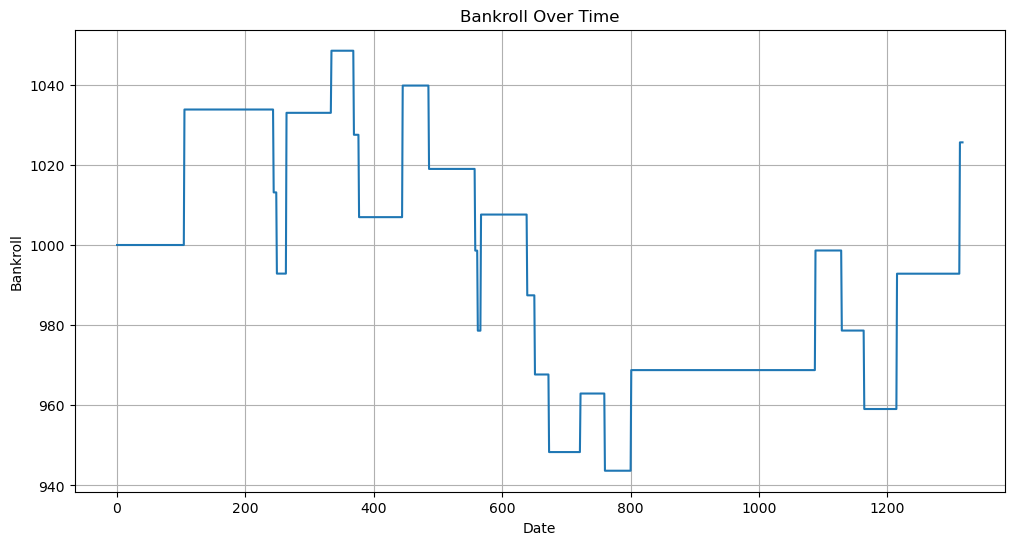

In [ ]:
#plot bets_df

import matplotlib.pyplot as plt
bets_df['bankroll'].plot(kind='line', figsize=(12, 6), title='Bankroll Over Time')
plt.xlabel('Date')
plt.ylabel('Bankroll')
plt.grid()





In [ ]:
# results = run_parallel_simulations(
#     seasons=["2022-23"], #, "2023-24"],
#     model_identifier="grid_odds",
#     reset_bankroll_each_season=False
# )


In [5]:


# Trouver le dernier fichier de résumé
summary_files = sorted([f for f in os.listdir(DATA_GRID_SIMULATIONS_BETS_DIR) if f.startswith("summary_grid_results")])
latest_summary_path = os.path.join(DATA_GRID_SIMULATIONS_BETS_DIR, summary_files[-1])

with open(latest_summary_path, 'r') as f:
    grid_results = json.load(f)

# Afficher les meilleurs runs par exemple par bankroll finale
sorted_results = sorted(
    [res for res in grid_results if "final_bankroll" in res],
    key=lambda x: x["final_bankroll"],
    reverse=True
)

for r in sorted_results[:10]:
    print(f"{r['param_suffix']} - Final bankroll: {r['final_bankroll']:.2f}, ROI: {r['roi']:.3f}, Wins: {r['wins']}/{r['total_bets']}")


IndexError: list index out of range